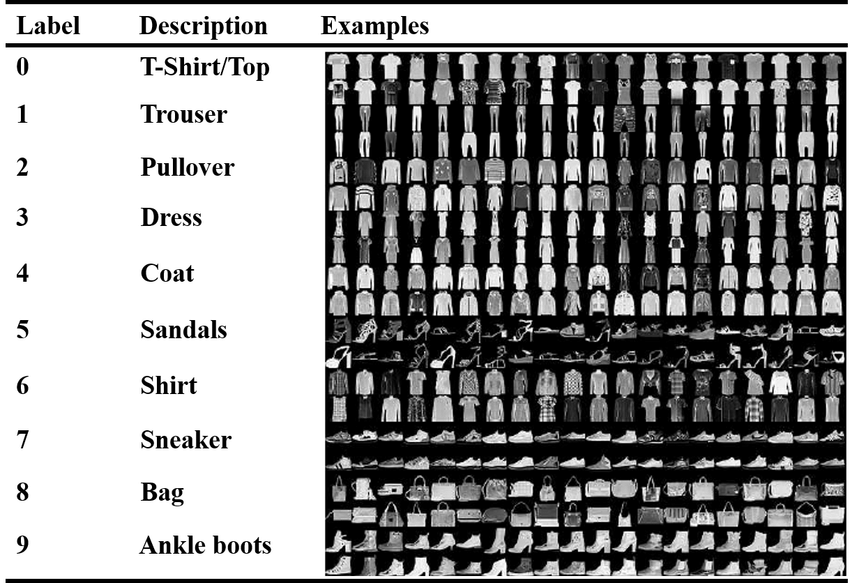

(60000, 28, 28)
(10000, 28, 28)


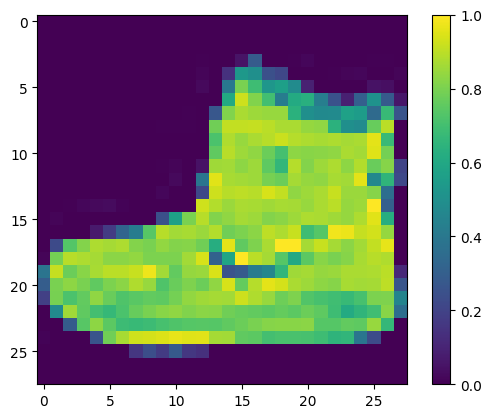

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8130 - loss: 0.5162 - val_accuracy: 0.8581 - val_loss: 0.3696
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8768 - loss: 0.3418 - val_accuracy: 0.8892 - val_loss: 0.3037
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8926 - loss: 0.2946 - val_accuracy: 0.8960 - val_loss: 0.2808
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9018 - loss: 0.2667 - val_accuracy: 0.9057 - val_loss: 0.2662
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9099 - loss: 0.2399 - val_accuracy: 0.9061 - val_loss: 0.2562
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9183 - loss: 0.2187 - val_accuracy: 0.9108 - val_loss: 0.2515
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9243 - loss: 0.2060 - val_accuracy: 0.9098 - val_loss: 0.2533
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9302 - loss: 0.1859 -

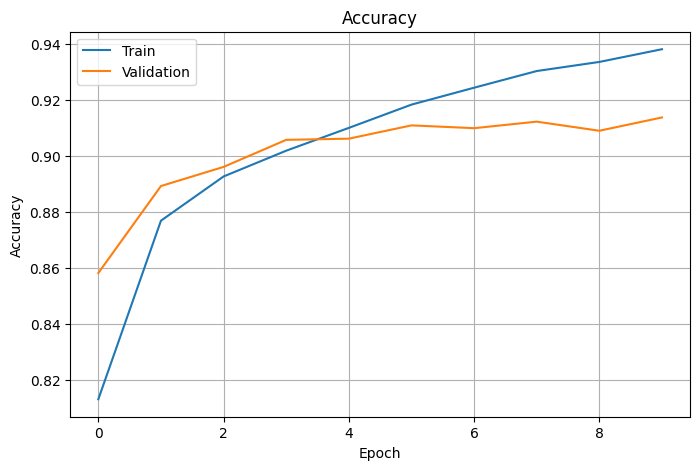

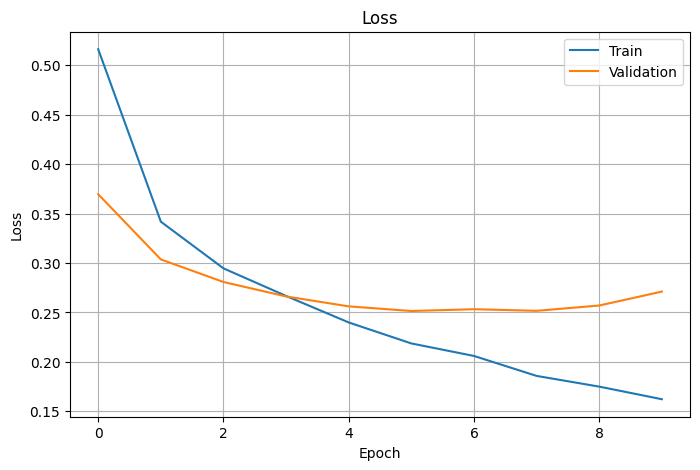

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


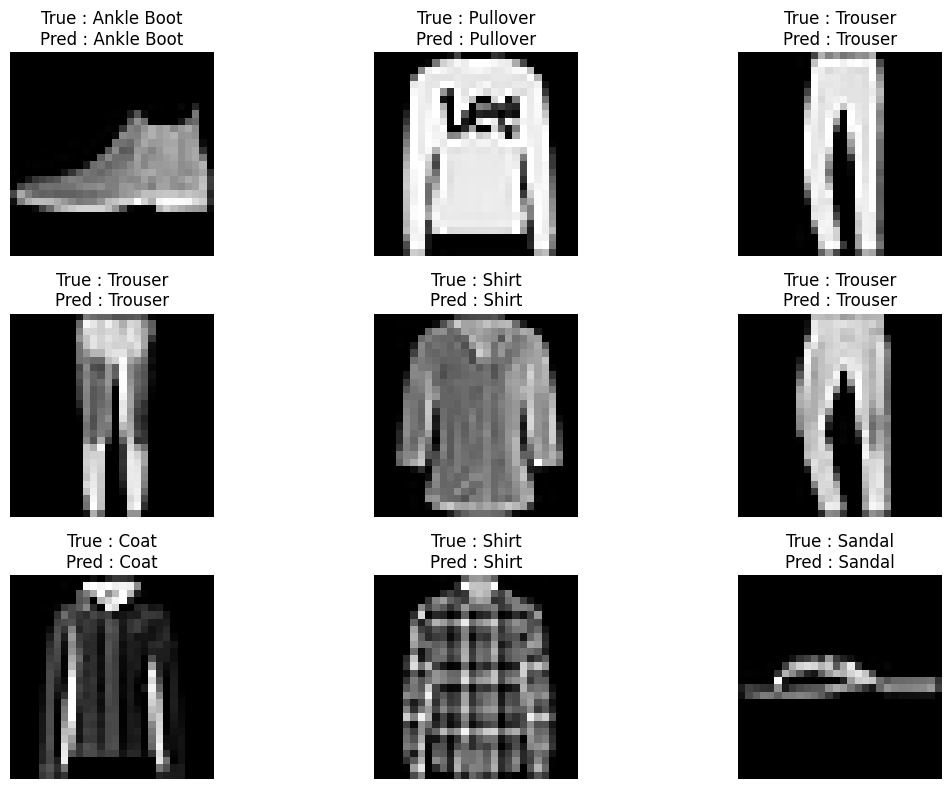

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

#------------------------------------
# 데이터 불러오기
#------------------------------------

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)
print(X_test.shape)

#------------------------------------
# 정규화
#------------------------------------

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# CNN 입력 형태
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

#------------------------------------
# 클래스 이름
#------------------------------------

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure()
plt.imshow(X_train[0])
plt.colorbar()
plt.grid(False)
plt.show()

#------------------------------------
# CNN 모델
#------------------------------------

model = Sequential([

    Input(shape=(28,28,1)),
    Conv2D(32,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.3),
    Dense(10,activation="softmax")

])

#------------------------------------
# 모델 확인
#------------------------------------

model.summary()

#------------------------------------
# 컴파일
#------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#------------------------------------
# 학습
#------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

#------------------------------------
# 평가
#------------------------------------

loss, accuracy = model.evaluate(X_test,y_test)

print("Loss :",loss)
print("Accuracy :",accuracy)

#------------------------------------
# Accuracy 그래프
#------------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Train")
plt.plot(history.history["val_accuracy"],label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

#------------------------------------
# Loss 그래프
#------------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

#------------------------------------
# 예측
#------------------------------------

pred = model.predict(X_test)

pred_class = np.argmax(pred,axis=1)

#------------------------------------
# 결과 출력
#------------------------------------

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap="gray"
    )

    plt.title(
        f"True : {class_names[y_test[i]]}\n"
        f"Pred : {class_names[pred_class[i]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()